In [100]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import os
from datetime import datetime
from openpyxl import load_workbook, Workbook
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
import numpy as np

## red wine quality

In [101]:
red = pd.read_csv("redwinequality.csv", sep=';')
white = pd.read_csv("whitewinequality.csv", sep=';')

red['type'] = 1
white['type'] = 0

wines = pd.concat([red, white], ignore_index=True)
wines.dropna(inplace=True)

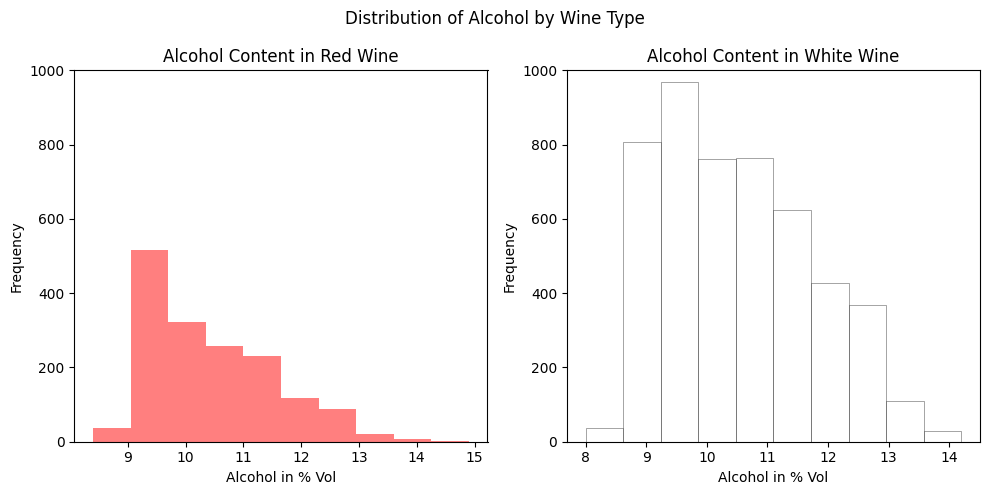

In [102]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(wines[wines['type'] == 1].alcohol, bins=10, facecolor='red', alpha=0.5, label='Red wine')
ax[1].hist(wines[wines['type'] == 0].alcohol, bins=10, facecolor='white', edgecolor='black', lw=0.5, alpha=0.5, label='White wine')

for a in ax:
    a.set_ylim([0, 1000])
    a.set_xlabel('Alcohol in % Vol')
    a.set_ylabel('Frequency')

ax[0].set_title('Alcohol Content in Red Wine')
ax[1].set_title('Alcohol Content in White Wine')

fig.suptitle('Distribution of Alcohol by Wine Type')
plt.tight_layout()
plt.show()

In [103]:
X = wines.iloc[:, :-1]
y = wines['type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.34, random_state=45)

In [104]:
model = Sequential()
model.add(Dense(12, activation='relu', input_dim=12))
model.add(Dense(9, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

c:\Users\onnok\NN-Project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [105]:
model.fit(X_train, y_train, epochs=3, batch_size=1, verbose=1)

Epoch 1/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 4s 722us/step - accuracy: 0.9237 - loss: 0.2150
Epoch 2/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 3s 721us/step - accuracy: 0.9445 - loss: 0.1597
Epoch 3/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 3s 688us/step - accuracy: 0.9566 - loss: 0.1267


In [106]:
y_pred = model.predict(X_test)

y_pred_labels = (y_pred >= 0.5).astype(int)

for prediction in y_pred_labels[:12]:
    wine_type = "Red wine" if prediction == 1 else "White wine"
    print(f"Prediction: {wine_type}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: Red wine
Prediction: Red wine
Prediction: White wine
Prediction: Red wine
Prediction: White wine
Prediction: White wine
Prediction: Red wine


## prediction Fashion

In [107]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [108]:
print("My train data Shape:", train_data.shape)
print("My train labels :", train_labels.shape)
print("Maximum label : ", train_labels.max())

My train data Shape: (60000, 28, 28)
My train labels : (60000,)
Maximum label :  9


Text(0.5, 1.0, 'Bag')

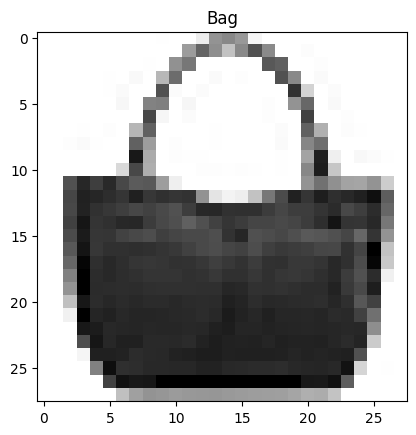

In [109]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
index_of_choice = 100
plt.imshow(train_data[index_of_choice],cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])

In [110]:
train_data_norm = train_data / train_data.max()
test_data_norm = test_data / test_data.max()

In [111]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape= train_data[0].shape),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(10, activation=tf.keras.activations.softmax)
])

model.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(0.001),
                metrics = ["Accuracy"])
norm_history = model.fit(train_data_norm,train_labels,epochs=10,validation_data=(test_data_norm, test_labels))

Epoch 1/10


c:\Users\onnok\NN-Project\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


 173/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 885us/step - Accuracy: 0.1634 - loss: 2.1987

KeyboardInterrupt: 

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step


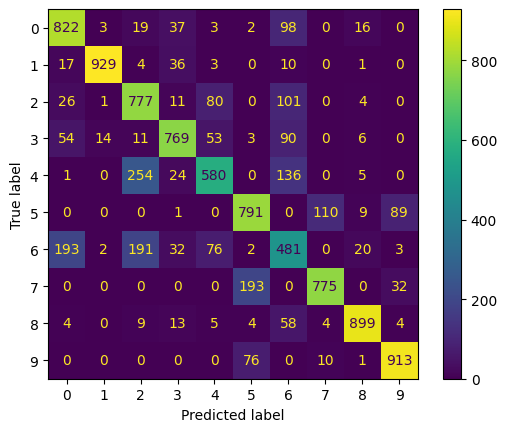

In [ ]:
y_pred_probs = model.predict(test_data_norm)

# Hoogste kans kiezen
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix maken
cm = confusion_matrix(test_labels, y_pred)

# Tonen
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Ameshousing

In [113]:
df = pd.read_excel("AmesHousing.xlsx")

In [114]:
df["Garage"] = df["Garage"].map({"yes": 1, "no": 0})
df = pd.get_dummies(df, columns=["Neighborhood", "House Style"], drop_first=True)

In [115]:
X = df.drop(["ID", "SalePrice"], axis=1)
y = df["SalePrice"]

In [116]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [117]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [118]:

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    verbose=1
)

Epoch 1/50


c:\Users\onnok\NN-Project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 37998227456.0000 - mae: 178640.6250 - val_loss: 40968900608.0000 - val_mae: 184719.0469
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37998284800.0000 - mae: 178640.6875 - val_loss: 40968749056.0000 - val_mae: 184718.6562
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 37998112768.0000 - mae: 178640.2500 - val_loss: 40968552448.0000 - val_mae: 184718.1250
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37997887488.0000 - mae: 178639.6250 - val_loss: 40968265728.0000 - val_mae: 184717.3438
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 37997559808.0000 - mae: 178638.7188 - val_loss: 40967872512.0000 - val_mae: 184716.2656
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37997133824.0000 - mae: 178637.4844 - val_loss: 40967372800.0000 - val_mae: 184714.9219
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37996580864.0000 - mae: 178635.9688 - val_loss: 40966742016.0000 - val_mae: 1

In [119]:
from sklearn.metrics import mean_absolute_error

pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)

print("MAE:", mae)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
MAE: 186623.078125


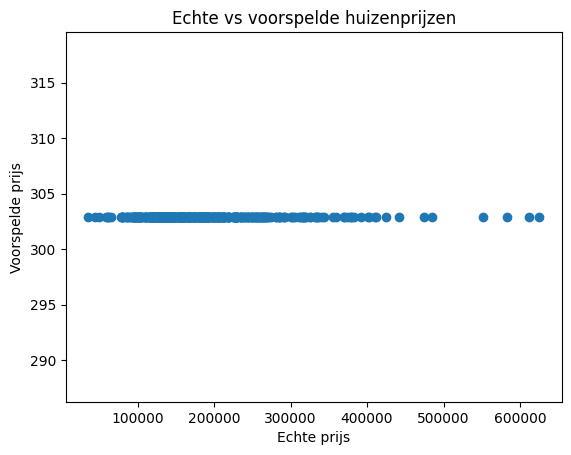

In [120]:

plt.scatter(y_test, pred)
plt.xlabel("Echte prijs")
plt.ylabel("Voorspelde prijs")
plt.title("Echte vs voorspelde huizenprijzen")
plt.show()

## ames minder features

In [121]:
df = df.loc[:, ["SalePrice", "Overall Qual",
    "Gr Liv Area",
    "Total Bsmt SF",
    "Year Built"]]

df

,SalePrice,Overall Qual,Gr Liv Area,Total Bsmt SF,Year Built
0,215000,6,1656,1080.0,1960
1,105000,5,896,882.0,1961
2,172000,6,1329,1329.0,1958
3,244000,7,2110,2110.0,1968
4,189900,5,1629,928.0,1997
...,...,...,...,...,...
2925,142500,6,1003,1003.0,1984
2926,131000,5,902,864.0,1983
2927,132000,5,970,912.0,1992
2928,170000,5,1389,1389.0,1974


In [122]:
X = df.drop(["SalePrice"], axis=1)
y = df["SalePrice"]

In [123]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [124]:
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_val_scaled = y_scaler.transform(y_val.values.reshape(-1,1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1,1))

In [125]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [126]:

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    verbose=1
)

Epoch 1/100


c:\Users\onnok\NN-Project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 37998424064.0000 - mae: 178641.1094 - val_loss: 40968921088.0000 - val_mae: 184719.1250
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37998272512.0000 - mae: 178640.7188 - val_loss: 40968663040.0000 - val_mae: 184718.3906
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37997850624.0000 - mae: 178639.5469 - val_loss: 40968011776.0000 - val_mae: 184716.6406
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37996949504.0000 - mae: 178637.0156 - val_loss: 40966742016.0000 - val_mae: 184713.2188
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37995343872.0000 - mae: 178632.5000 - val_loss: 40964648960.0000 - val_mae: 184707.5156
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37992873984.0000 - mae: 178625.5781 - val_loss: 40961568768.0000 - val_mae: 184699.2188
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37989359616.0000 - mae: 178615.7031 - val_loss: 40957288448.0000 - val_

In [127]:
from sklearn.metrics import mean_absolute_error

pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)

print("MAE:", mae)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
MAE: 150140.578125


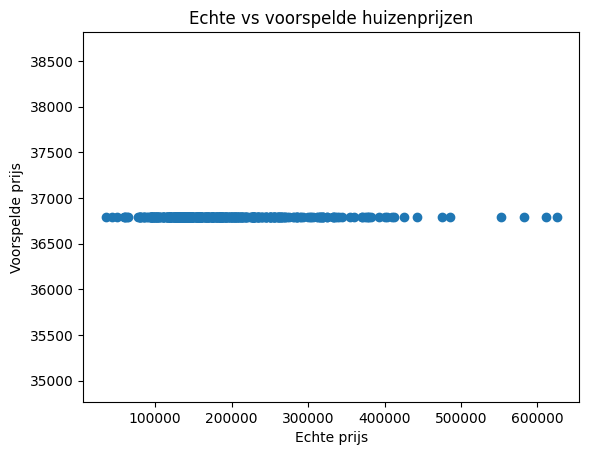

In [128]:

plt.scatter(y_test, pred)
plt.xlabel("Echte prijs")
plt.ylabel("Voorspelde prijs")
plt.title("Echte vs voorspelde huizenprijzen")
plt.show()